<a href="https://colab.research.google.com/github/AkshitaNipane/Machine-Learning-TAE/blob/main/machine_learning_4_(KNN_Model).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/ML_DATASET/customer_feedback_satisfaction.csv')

In [ ]:
# Display dataset
print("Dataset Preview:")
print(df.head())


Dataset Preview:
   CustomerID  Age  Gender Country  Income  ProductQuality  ServiceQuality  \
0           1   56    Male      UK   83094               5               8   
1           2   69    Male      UK   86860              10               2   
2           3   46  Female     USA   60173               8              10   
3           4   32  Female      UK   73884               7              10   
4           5   60    Male      UK   97546               6               4   

   PurchaseFrequency FeedbackScore LoyaltyLevel  SatisfactionScore  
0                  5           Low       Bronze              100.0  
1                  8        Medium         Gold              100.0  
2                 18        Medium       Silver              100.0  
3                 16           Low         Gold              100.0  
4                 13           Low       Bronze               82.0  


In [ ]:
df.shape

(38444, 11)

In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Country', 'Income', 'ProductQuality',
       'ServiceQuality', 'PurchaseFrequency', 'FeedbackScore', 'LoyaltyLevel',
       'SatisfactionScore'],
      dtype='object')

In [ ]:
df.describe()

,CustomerID,Age,Gender,Country,Income,ProductQuality,ServiceQuality,PurchaseFrequency,FeedbackScore,LoyaltyLevel,SatisfactionScore
count,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000,38444.000000
mean,19222.500000,43.496853,0.498127,2.001535,75076.619238,5.494746,5.492769,10.453881,0.995422,0.998023,85.276409
std,11097.971211,14.972748,0.500003,1.416685,25975.752966,2.873192,2.875812,5.765621,0.816983,0.814953,16.898577
min,1.000000,18.000000,0.000000,0.000000,30001.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.280000
25%,9611.750000,31.000000,0.000000,1.000000,52624.500000,3.000000,3.000000,5.000000,0.000000,0.000000,74.470000
50%,19222.500000,43.000000,0.000000,2.000000,75236.000000,5.000000,5.000000,10.000000,1.000000,1.000000,91.270000
75%,28833.250000,56.000000,1.000000,3.000000,97606.750000,8.000000,8.000000,15.000000,2.000000,2.000000,100.000000
max,38444.000000,69.000000,1.000000,4.000000,119999.000000,10.000000,10.000000,20.000000,2.000000,2.000000,100.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38444 entries, 0 to 38443
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         38444 non-null  int64  
 1   Age                38444 non-null  int64  
 2   Gender             38444 non-null  int64  
 3   Country            38444 non-null  int64  
 4   Income             38444 non-null  int64  
 5   ProductQuality     38444 non-null  int64  
 6   ServiceQuality     38444 non-null  int64  
 7   PurchaseFrequency  38444 non-null  int64  
 8   FeedbackScore      38444 non-null  int64  
 9   LoyaltyLevel       38444 non-null  int64  
 10  SatisfactionScore  38444 non-null  float64
dtypes: float64(1), int64(10)
memory usage: 3.2 MB


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor   # ✅ Changed
from sklearn.metrics import mean_squared_error, r2_score

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/ML_DATASET/customer_feedback_satisfaction.csv')

print("Dataset Preview:")
print(df.head())

# ---------------------------
# Data Preprocessing
# ---------------------------

le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

# Scaling (VERY IMPORTANT for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------
# FUNCTION
# ---------------------------

def knn_model(split_ratio):
    print(f"\n===== KNN REGRESSOR ({int(split_ratio*100)}:{int((1-split_ratio)*100)}) =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=(1-split_ratio), random_state=42
    )

    model = KNeighborsRegressor(n_neighbors=5)   # ✅ Changed
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Output Table
    result_table = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred
    })

    print("\nMean Squared Error:", mse)
    print("R-squared:", r2)

    print("\nOutput Table:")
    print(result_table.head(10))

    return mse, r2, result_table


# ---------------------------
# 80:20 Split
# ---------------------------
mse_80, r2_80, knn_table_80 = knn_model(0.8)

# ---------------------------
# 70:30 Split
# ---------------------------
mse_70, r2_70, knn_table_70 = knn_model(0.7)

Mounted at /content/drive
Dataset Preview:
   CustomerID  Age  Gender Country  Income  ProductQuality  ServiceQuality  \
0           1   56    Male      UK   83094               5               8   
1           2   69    Male      UK   86860              10               2   
2           3   46  Female     USA   60173               8              10   
3           4   32  Female      UK   73884               7              10   
4           5   60    Male      UK   97546               6               4   

   PurchaseFrequency FeedbackScore LoyaltyLevel  SatisfactionScore  
0                  5           Low       Bronze              100.0  
1                  8        Medium         Gold              100.0  
2                 18        Medium       Silver              100.0  
3                 16           Low         Gold              100.0  
4                 13           Low       Bronze               82.0  

===== KNN REGRESSOR (80:19) =====

Mean Squared Error: 82.93554633320328


In [ ]:
# Convert categorical columns to numeric
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [ ]:
# Split features and target
X = df.drop(df.columns[-1], axis=1)   # Features
y_continuous = df[df.columns[-1]]               # Original continuous Target

# Discretize the continuous 'SatisfactionScore' into categories for classification
bins = [0, 60, 80, 100]
labels = ['Low', 'Medium', 'High']
y_categorized = pd.cut(y_continuous, bins=bins, labels=labels, include_lowest=True)

# Encode the categorical target labels into numerical values
le_y = LabelEncoder()
y = le_y.fit_transform(y_categorized)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
def knn_model(split_ratio):
    print(f"\n===== KNN Model ({int(split_ratio*100)}:{int((1-split_ratio)*100)}) Split =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=(1-split_ratio), random_state=42
    )

    # Model
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediction
    y_pred = knn.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.2f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Classification Report
    cr = classification_report(y_test, y_pred)
    print("\nClassification Report:")
    print(cr)

    # Output Table
    result_table = pd.DataFrame({
        'Actual': y_test,
        'Predicted': y_pred
    })

    return acc, result_table

In [ ]:
acc_70, table_70 = knn_model(0.7)


===== KNN Model (70:30) Split =====
Accuracy: 0.76

Confusion Matrix:
[[7162   52  529]
 [ 135  615  422]
 [1285  351  983]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.88      7743
           1       0.60      0.52      0.56      1172
           2       0.51      0.38      0.43      2619

    accuracy                           0.76     11534
   macro avg       0.65      0.61      0.62     11534
weighted avg       0.74      0.76      0.74     11534



In [ ]:
acc_80, table_80 = knn_model(0.8)


===== KNN Model (80:19) Split =====
Accuracy: 0.76

Confusion Matrix:
[[4782   28  357]
 [  80  409  265]
 [ 880  238  650]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      5167
           1       0.61      0.54      0.57       754
           2       0.51      0.37      0.43      1768

    accuracy                           0.76      7689
   macro avg       0.65      0.61      0.63      7689
weighted avg       0.74      0.76      0.74      7689



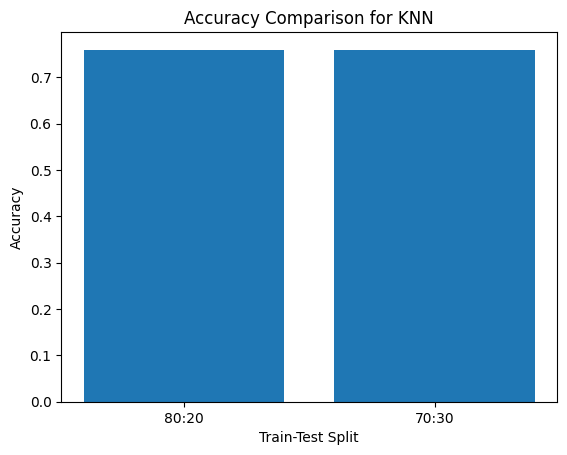

In [ ]:
splits = ['80:20', '70:30']
accuracies = [acc_80, acc_70]

plt.figure()
plt.bar(splits, accuracies)
plt.title("Accuracy Comparison for KNN")
plt.xlabel("Train-Test Split")
plt.ylabel("Accuracy")
plt.show()

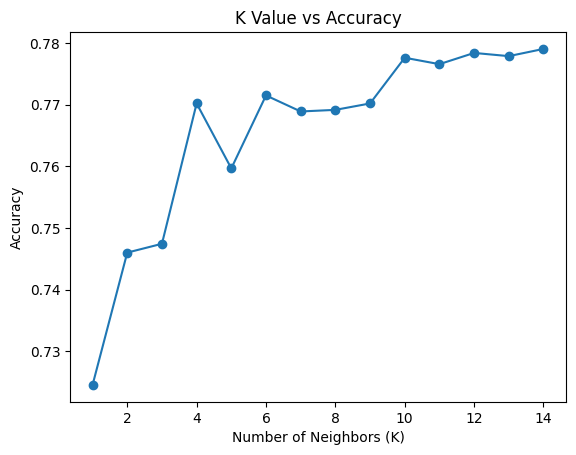

In [ ]:
k_values = range(1, 15)
scores = []

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(k_values, scores, marker='o')
plt.title("K Value vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# KNN with GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3)

grid.fit(X_scaled, y)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}


In [ ]:
# Create summary table

summary = pd.DataFrame({
    'Split': ['80:20', '70:30'],
    'Accuracy': [acc_80, acc_70]
})

print("\nAccuracy Comparison Table:")
print(summary)


Accuracy Comparison Table:
   Split  Accuracy
0  80:20  0.759657
1  70:30  0.759494


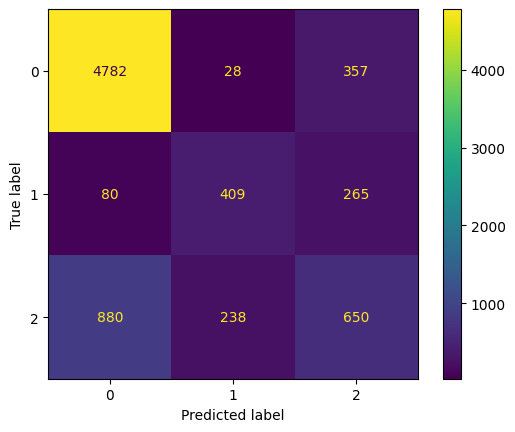

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.show()

In [ ]:
for k in [3,5,7,9]:
    print(f"\n--- K = {k} ---")

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))


--- K = 3 ---
Accuracy: 0.747431395500065

--- K = 5 ---
Accuracy: 0.759656652360515

--- K = 7 ---
Accuracy: 0.7688906229678761

--- K = 9 ---
Accuracy: 0.7701911822083496


In [ ]:
import time

start = time.time()

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

end = time.time()

print("Training Time:", end - start)

Training Time: 0.10234498977661133


In [ ]:
# Example new input (modify according to dataset)

new_data = np.array([X.iloc[0]])
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

print("Predicted Output:", prediction)

Predicted Output: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
